## Klassifikation 

#  Bibliotheken laden

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, PolynomialFeatures

from sklearn.compose import ColumnTransformer

# Pipeline
from sklearn.pipeline import Pipeline

# Klassifikation
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Train/Test Split & Metriken
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Cross Validation und GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

import warnings
warnings.filterwarnings("ignore")


In [45]:
# Datensatz in Erste Teile vorbereitet laden Überblick
df = pd.read_csv('Marktkampagne_V2.csv')
df.head(10)

,ID,Geburtsjahr,Alter,Einkommen,Bildungsniveau,Familienstand,Kinder_zu_Hause,Teenager_zu_Hause,Gesamt_Kinder,Datum_Kunde,...,Anzahl_Webkäufe,Anzahl_WebBesuche_Monat,Kampagne_1_Akzeptiert,Kampagne_2_Akzeptiert,Kampagne_3_Akzeptiert,Kampagne_4_Akzeptiert,Kampagne_5_Akzeptiert,Antwort_Letzte_Kampagne,Beschwerde,Kundenbindungsdauer
0,5524,1967,59,58138.0,Hochschulabschluss,Ledig,0,0,0,2022-09-04,...,8,7,0,0,0,0,0,1,0,1243
1,2174,1964,62,46344.0,Hochschulabschluss,Ledig,1,1,2,2024-03-08,...,1,5,0,0,0,0,0,0,0,692
2,4141,1975,51,71613.0,Hochschulabschluss,Zusammenlebend,0,0,0,2023-08-21,...,8,4,0,0,0,0,0,0,0,892
3,6182,1994,32,26646.0,Hochschulabschluss,Zusammenlebend,1,0,1,2024-02-10,...,2,6,0,0,0,0,0,0,0,719
4,5324,1991,35,58293.0,Doktor,Verheiratet,1,0,1,2024-01-19,...,5,5,0,0,0,0,0,0,0,741
5,7446,1977,49,62513.0,Master,Zusammenlebend,0,1,1,2023-09-09,...,6,6,0,0,0,0,0,0,0,873
6,965,1981,45,55635.0,Hochschulabschluss,Geschieden,0,1,1,2022-11-13,...,7,6,0,0,0,0,0,0,0,1173
7,6177,1995,31,33454.0,Doktor,Verheiratet,1,0,1,2023-05-08,...,4,8,0,0,0,0,0,0,0,997
8,4855,1984,42,30351.0,Doktor,Zusammenlebend,1,0,1,2023-06-06,...,3,9,0,0,0,0,0,1,0,968
9,5899,1960,66,5648.0,Doktor,Zusammenlebend,1,1,2,2024-03-13,...,1,20,0,0,1,0,0,0,0,687


In [4]:
df.columns

Index(['ID', 'Geburtsjahr', 'Alter', 'Einkommen', 'Bildungsniveau',
       'Familienstand', 'Kinder_zu_Hause', 'Teenager_zu_Hause',
       'Gesamt_Kinder', 'Datum_Kunde', 'Kundenbindungsdauer',
       'Letzter_Kauf_Tage', 'Kundenbindungsdauer_Jahre', 'Ausgaben_Wein',
       'Ausgaben_Fleisch', 'Ausgaben_Obst', 'Ausgaben_Fisch',
       'Ausgaben_Süßigkeiten', 'Ausgaben_Gold', 'Ausgaben_pro_Jahr',
       'Gesamt_Ausgaben', 'Wein_Anteil', 'Wein_Anteil_Prozent',
       'Anzahl_Rabattkäufe', 'Anzahl_Katalogkäufe', 'Anzahl_Ladeneinkäufe',
       'Anzahl_Webkäufe', 'Anzahl_WebBesuche_Monat', 'Kampagne_1_Akzeptiert',
       'Kampagne_2_Akzeptiert', 'Kampagne_3_Akzeptiert',
       'Kampagne_4_Akzeptiert', 'Kampagne_5_Akzeptiert',
       'Antwort_Letzte_Kampagne', 'Beschwerde'],
      dtype='object')

# Random Forest 
### Features & Zielvariable definier

In [5]:
# Zielvariablen
targets = [
    'Kampagne_1_Akzeptiert', 'Kampagne_2_Akzeptiert', 
    'Kampagne_3_Akzeptiert', 'Kampagne_4_Akzeptiert', 
    'Kampagne_5_Akzeptiert', 'Antwort_Letzte_Kampagne'
]

# Numerische Features
numerical_features = [
    'Alter', 'Einkommen', 'Gesamt_Kinder', 'Kundenbindungsdauer_Jahre', 
    'Letzter_Kauf_Tage',
    'Ausgaben_Wein','Ausgaben_Fleisch','Ausgaben_Obst','Ausgaben_Fisch','Ausgaben_Süßigkeiten','Ausgaben_Gold','Ausgaben_pro_Jahr',
    'Wein_Anteil','Anzahl_Rabattkäufe',
    'Anzahl_Katalogkäufe','Anzahl_Ladeneinkäufe','Anzahl_Webkäufe','Anzahl_WebBesuche_Monat'
]

# Kategorische Features
categorical_features = ['Bildungsniveau', 'Familienstand']

# Features und Target vorbereiten
X = df[numerical_features + categorical_features]
y = df[targets]


In [6]:
transformer = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])


In [7]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:


# Pipeline
multi_pipeline = Pipeline([
    ('transformer', transformer),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            class_weight='balanced',  # hilft bei unbalancierten Klassen
            random_state=42
        )
    ))
])




##  Modellbewertung - Random Forest

In [9]:
from sklearn.metrics import f1_score

multi_pipeline.fit(X_train, y_train)
y_pred = multi_pipeline.predict(X_test)
y_pred = pd.DataFrame(y_pred, columns=targets)

for col in targets:
    score = f1_score(y_test[col], y_pred[col])
    print(f"{col}: F1 = {score:.3f}")


Kampagne_1_Akzeptiert: F1 = 0.485
Kampagne_2_Akzeptiert: F1 = 0.000
Kampagne_3_Akzeptiert: F1 = 0.051
Kampagne_4_Akzeptiert: F1 = 0.448
Kampagne_5_Akzeptiert: F1 = 0.507
Antwort_Letzte_Kampagne: F1 = 0.453


In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

f1_scores_per_fold = {col: [] for col in targets}

for train_idx, val_idx in kf.split(X):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    
    # Trainieren
    multi_pipeline.fit(X_train_cv, y_train_cv)
    
    # Vorhersage
    y_pred_cv = pd.DataFrame(multi_pipeline.predict(X_val_cv), columns=targets)
    
    # F1 pro Kampagne speichern
    for col in targets:
        f1_scores_per_fold[col].append(f1_score(y_val_cv[col], y_pred_cv[col]))


In [12]:
for col in targets:
    scores = f1_scores_per_fold[col]
    print(f"{col}: Mean F1 = {np.mean(scores):.3f}, Std = {np.std(scores):.3f}")


Kampagne_1_Akzeptiert: Mean F1 = 0.448, Std = 0.078
Kampagne_2_Akzeptiert: Mean F1 = 0.000, Std = 0.000
Kampagne_3_Akzeptiert: Mean F1 = 0.121, Std = 0.050
Kampagne_4_Akzeptiert: Mean F1 = 0.430, Std = 0.071
Kampagne_5_Akzeptiert: Mean F1 = 0.577, Std = 0.069
Antwort_Letzte_Kampagne: Mean F1 = 0.443, Std = 0.029


In [13]:
# Trainieren
multi_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('transformer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [14]:
# Vorhersage
y_pred = multi_pipeline.predict(X_test)
y_pred = pd.DataFrame(y_pred, columns=targets)

In [15]:
for col in targets:
    print(f"--- {col} ---")
    print(classification_report(y_test[col], y_pred[col]))

--- Kampagne_1_Akzeptiert ---
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       377
           1       0.40      0.62      0.48        26

    accuracy                           0.92       403
   macro avg       0.69      0.78      0.72       403
weighted avg       0.94      0.92      0.92       403

--- Kampagne_2_Akzeptiert ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       399
           1       0.00      0.00      0.00         4

    accuracy                           0.99       403
   macro avg       0.50      0.50      0.50       403
weighted avg       0.98      0.99      0.98       403

--- Kampagne_3_Akzeptiert ---
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       371
           1       0.14      0.03      0.05        32

    accuracy                           0.91       403
   macro avg       0.53      0.51     

In [16]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline

# Scorer für RandomizedSearchCV
f1_macro_scorer = make_scorer(f1_score, average='macro')

# Parameter-Raum
param_dist = {
    'classifier__estimator__n_estimators': [100, 200, 300, 400],
    'classifier__estimator__max_depth': [5, 8, 12, None],
    'classifier__estimator__min_samples_split': [2, 5, 10],
    'classifier__estimator__min_samples_leaf': [1, 2, 4],
    'classifier__estimator__max_features': ['sqrt', 'log2', None]
}

# Pipeline bleibt gleich
pipeline = Pipeline([
    ('transformer', transformer),
    ('classifier', MultiOutputClassifier(RandomForestClassifier(class_weight='balanced', random_state=42)))
])

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,            # Anzahl der zufälligen Kombinationen
    scoring=f1_macro_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)



In [18]:
palette = [
    "#0A1AFF",  
    "#FF9A35",  
    "#E87A8A",  
    "#FFEA00"   
]

--- Top Features für Kampagne_1_Akzeptiert ---
                      Feature  Importance
1                   Einkommen    0.168780
11          Ausgaben_pro_Jahr    0.168006
5               Ausgaben_Wein    0.118514
14        Anzahl_Katalogkäufe    0.087285
6            Ausgaben_Fleisch    0.085485
9        Ausgaben_Süßigkeiten    0.041714
8              Ausgaben_Fisch    0.035156
3   Kundenbindungsdauer_Jahre    0.032861
12                Wein_Anteil    0.032402
7               Ausgaben_Obst    0.028222


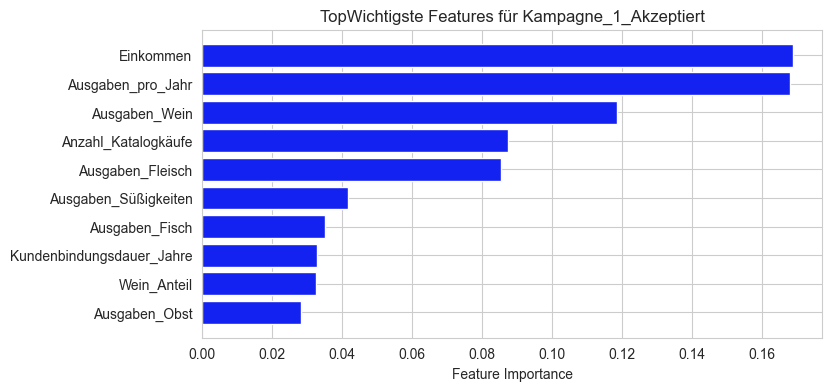

--- Top Features für Kampagne_2_Akzeptiert ---
                 Feature  Importance
5          Ausgaben_Wein    0.203929
12           Wein_Anteil    0.135611
11     Ausgaben_pro_Jahr    0.126041
1              Einkommen    0.076840
14   Anzahl_Katalogkäufe    0.071711
6       Ausgaben_Fleisch    0.062193
10         Ausgaben_Gold    0.038865
9   Ausgaben_Süßigkeiten    0.031967
7          Ausgaben_Obst    0.031939
0                  Alter    0.028755


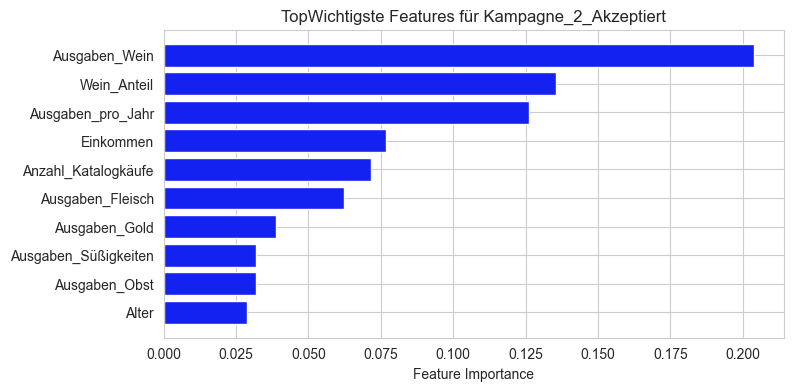

--- Top Features für Kampagne_3_Akzeptiert ---
                 Feature  Importance
10         Ausgaben_Gold    0.154824
15  Anzahl_Ladeneinkäufe    0.090892
11     Ausgaben_pro_Jahr    0.067052
1              Einkommen    0.062453
4      Letzter_Kauf_Tage    0.059748
14   Anzahl_Katalogkäufe    0.059603
5          Ausgaben_Wein    0.055613
6       Ausgaben_Fleisch    0.055001
0                  Alter    0.054637
12           Wein_Anteil    0.049909


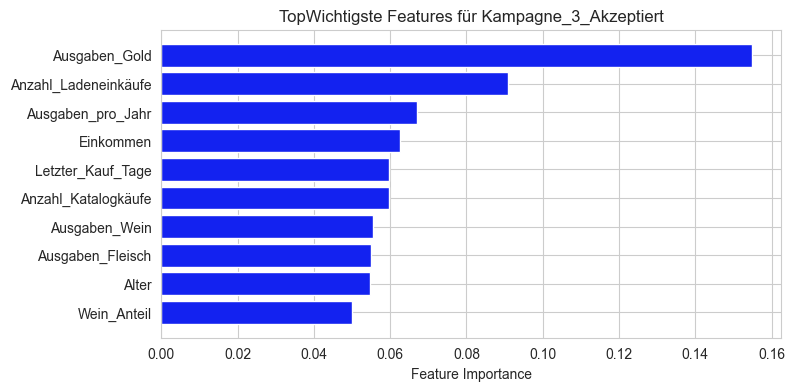

--- Top Features für Kampagne_4_Akzeptiert ---
                 Feature  Importance
5          Ausgaben_Wein    0.199013
12           Wein_Anteil    0.188353
11     Ausgaben_pro_Jahr    0.108490
1              Einkommen    0.094345
6       Ausgaben_Fleisch    0.060201
7          Ausgaben_Obst    0.035042
15  Anzahl_Ladeneinkäufe    0.034096
10         Ausgaben_Gold    0.032702
16       Anzahl_Webkäufe    0.032423
14   Anzahl_Katalogkäufe    0.030699


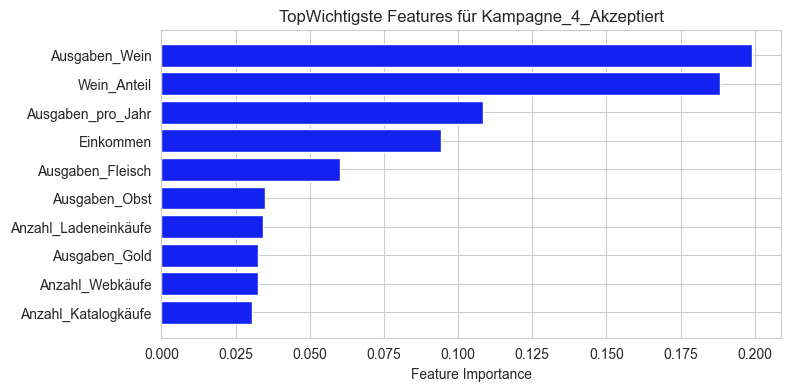

--- Top Features für Kampagne_5_Akzeptiert ---
                 Feature  Importance
1              Einkommen    0.237721
5          Ausgaben_Wein    0.166697
11     Ausgaben_pro_Jahr    0.151920
6       Ausgaben_Fleisch    0.078666
14   Anzahl_Katalogkäufe    0.058698
2          Gesamt_Kinder    0.041085
7          Ausgaben_Obst    0.035392
9   Ausgaben_Süßigkeiten    0.032908
12           Wein_Anteil    0.030144
13    Anzahl_Rabattkäufe    0.029117


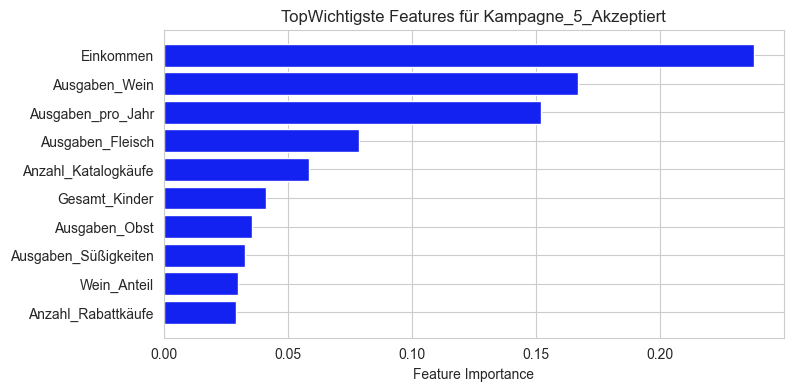

--- Top Features für Antwort_Letzte_Kampagne ---
                      Feature  Importance
4           Letzter_Kauf_Tage    0.105531
3   Kundenbindungsdauer_Jahre    0.096784
5               Ausgaben_Wein    0.086596
10              Ausgaben_Gold    0.074181
6            Ausgaben_Fleisch    0.070805
1                   Einkommen    0.067935
14        Anzahl_Katalogkäufe    0.058110
11          Ausgaben_pro_Jahr    0.056461
15       Anzahl_Ladeneinkäufe    0.052139
17    Anzahl_WebBesuche_Monat    0.047342


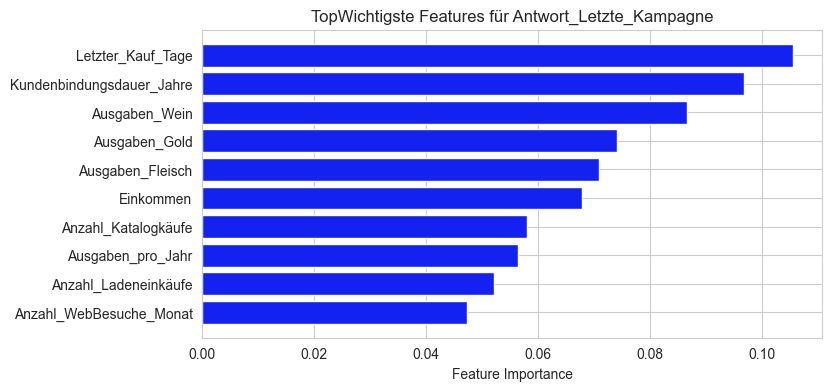

In [19]:
# Zugriff auf RandomForest-Klassen
rf_models = multi_pipeline.named_steps['classifier'].estimators_

for i, col in enumerate(targets):
    importances = rf_models[i].feature_importances_
    
    # Alle Feature-Namen aus ColumnTransformer
    cat_features = transformer.named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_features = numerical_features + list(cat_features)
    
    # Top 10 Features
    feat_imp = pd.DataFrame({
        'Feature': all_features,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(10)
    
    print(f"--- Top Features für {col} ---")
    print(feat_imp)
    
    # Balkendiagramm
    plt.figure(figsize=(8,4))
    plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1], color=  "#1322F0" )
    plt.title(f'TopWichtigste Features für {col}')
    plt.xlabel('Feature Importance')
    plt.show()

In [20]:
palette = [ "#FBEF09",'#0A1AFF',  "#6C94FA", "#BDD7F2",  '#FF9A35', '#E87A8A']

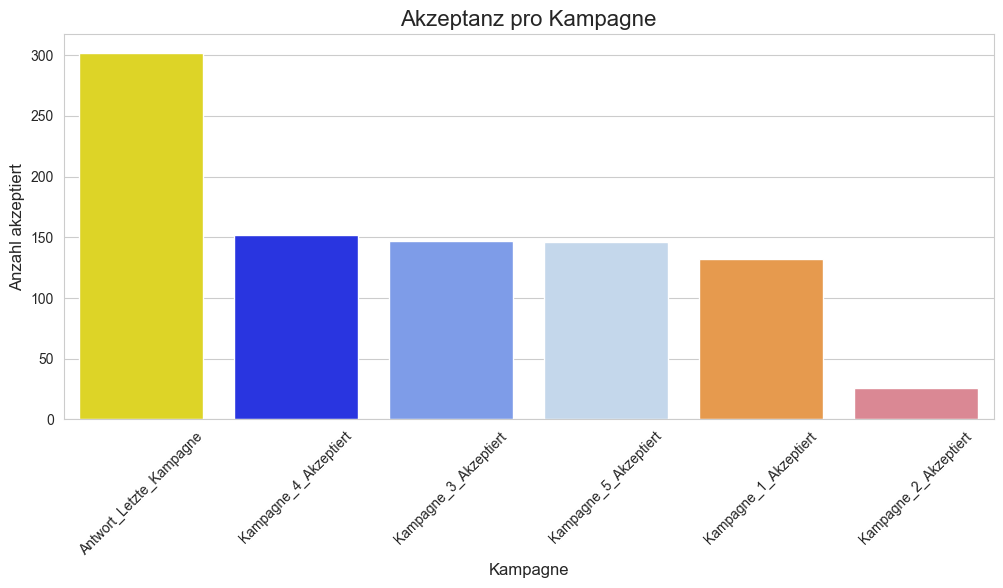

In [21]:
kampagnen_spalten = [
    "Kampagne_1_Akzeptiert","Kampagne_2_Akzeptiert",
    "Kampagne_3_Akzeptiert","Kampagne_4_Akzeptiert","Kampagne_5_Akzeptiert", 'Antwort_Letzte_Kampagne'
]

# Summe der Akzeptanzen pro Kampagne
kampagnen_counts = df[kampagnen_spalten].sum().sort_values(ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(
    x=kampagnen_counts.index,
    y=kampagnen_counts.values,
    palette= palette  
)
plt.title("Akzeptanz pro Kampagne", fontsize=16)
plt.ylabel("Anzahl akzeptiert", fontsize=12)
plt.xlabel("Kampagne", fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [22]:
kampagnen = [
    'Kampagne_1_Akzeptiert',
    'Kampagne_2_Akzeptiert',
    'Kampagne_3_Akzeptiert',
    'Kampagne_4_Akzeptiert',
    'Kampagne_5_Akzeptiert',
    'Antwort_Letzte_Kampagne'
]

avg_income_per_campaign = {}

for k in kampagnen:
    avg_income_per_campaign[k] = df.loc[df[k] == 1, 'Einkommen'].mean()

avg_income_per_campaign


{'Kampagne_1_Akzeptiert': np.float64(78768.34090909091),
 'Kampagne_2_Akzeptiert': np.float64(71451.57692307692),
 'Kampagne_3_Akzeptiert': np.float64(50999.29931972789),
 'Kampagne_4_Akzeptiert': np.float64(68151.52631578948),
 'Kampagne_5_Akzeptiert': np.float64(82416.8904109589),
 'Antwort_Letzte_Kampagne': np.float64(60170.003311258275)}

In [23]:
vergleich = {}

for k in kampagnen:
    vergleich[k] = {
        'Antworter': df.loc[df[k] == 1, 'Einkommen'].mean(),
        'Nicht_Antworter': df.loc[df[k] == 0, 'Einkommen'].mean()
    }

vergleich_df = pd.DataFrame(vergleich).T
vergleich_df


,Antworter,Nicht_Antworter
Kampagne_1_Akzeptiert,78768.340909,50193.082757
Kampagne_2_Akzeptiert,71451.576923,51814.852645
Kampagne_3_Akzeptiert,50999.299320,52153.072157
Kampagne_4_Akzeptiert,68151.526316,50753.733997
Kampagne_5_Akzeptiert,82416.890411,49692.953083
Antwort_Letzte_Kampagne,60170.003311,50637.145992


In [24]:
df['Einkommen'].mean()

np.float64(52068.73371456987)

### Random Forest: `Antwort_Letzte_Kampagne` als Zielvariable  
Zur Auswahl des besten Modells wird eine Hyperparameter-Optimierung mittels GridSearchCV durchgeführt.


In [25]:
# Zielvariablen
targets =  'Antwort_Letzte_Kampagne'


# Numerische Features
numerical_features = [
    'Alter', 'Einkommen', 'Gesamt_Kinder', 'Kundenbindungsdauer_Jahre', 
    'Letzter_Kauf_Tage',
    'Ausgaben_Wein','Ausgaben_Fleisch','Ausgaben_Obst','Ausgaben_Fisch','Ausgaben_Süßigkeiten','Ausgaben_Gold','Ausgaben_pro_Jahr',
    'Wein_Anteil','Anzahl_Rabattkäufe',
    'Anzahl_Katalogkäufe','Anzahl_Ladeneinkäufe','Anzahl_Webkäufe','Anzahl_WebBesuche_Monat'
]

# Kategorische Features
categorical_features = ['Bildungsniveau', 'Familienstand']

# Features und Target vorbereiten
X = df[numerical_features + categorical_features]
y = df[targets]

In [26]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:

# Spaltentransformation
transformer = ColumnTransformer([
    ('numerical_pl', StandardScaler(), numerical_features),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False),categorical_features)
])

# Gesamt-Pipeline Random Forest
pipeline = Pipeline([
    ('col_transformer', transformer),
    ('rf_model', RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_leaf=5, random_state=87))
])

In [28]:
# Durchführung der Crossvalidierung

cv_res = cross_validate(pipeline, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
print(cv_res['test_score'])
# n_jobs=-1 bedeutet, dass nicht pararallel gerechnet wird 

[0.80230712 0.79575862 0.80426868 0.82079262 0.80565496]


In [29]:
param_grid = {
    'rf_model__n_estimators': [100, 200],
    'rf_model__max_depth': [5, 8, None],
    'rf_model__min_samples_split': [2, 5],
    'rf_model__min_samples_leaf': [1, 5, 10],
    'rf_model__random_state': [42]  # fixieren für Reproduzierbarkeit
}
# 2) GridSearchCV einrichten
grid = GridSearchCV(
    estimator=pipeline,           # deine Pipeline (mit ColumnTransformer + RF)
    param_grid=param_grid,
    scoring='f1_weighted',        # zur Klassifikation oft sinnvoll
    cv=5,                         # 5-fold, automatisch stratifiziert
    n_jobs=-1,                    # optional: parallel, weglassen = seriell
    refit=True                    # bestes Modell wird am Ende auf X_train neu gefittet
)




In [30]:
grid.fit(X, y)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=87))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf_model__max_depth': [5, 8, ...], 'rf_model__min_samples_leaf': [1, 5, ...], 'rf_model__min_samples_split': [2, 5], 'rf_model__n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : t

In [31]:
print("Beste Parameter:", grid.best_params_)
print("Bestes F1-Score:", grid.best_score_)


Beste Parameter: {'rf_model__max_depth': None, 'rf_model__min_samples_leaf': 1, 'rf_model__min_samples_split': 5, 'rf_model__n_estimators': 200, 'rf_model__random_state': 42}
Bestes F1-Score: 0.8276788942299949


### Modellbewertung RF- GridSearchCV

In [32]:
best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       345
           1       1.00      0.97      0.98        58

    accuracy                           1.00       403
   macro avg       1.00      0.98      0.99       403
weighted avg       1.00      1.00      1.00       403



Confusion Matrix

In [33]:
cm = confusion_matrix(y_test, y_test_pred)

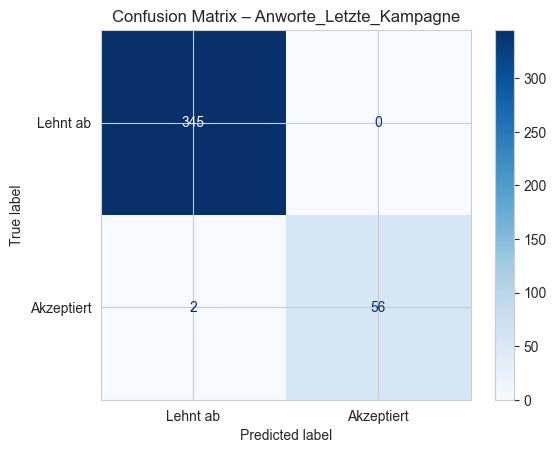

In [34]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Lehnt ab", "Akzeptiert"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Anworte_Letzte_Kampagne")
plt.show()

In [35]:
best_model = grid.best_estimator_



In [36]:
# ColumnTransformer aus der Pipeline
ct = best_model.named_steps['col_transformer']

# numerische Features
num_features = numerical_features

# OneHot-Feature-Namen
cat_features = (
    ct.named_transformers_['onehot']
    .get_feature_names_out(categorical_features)
)

# Alle Feature-Namen zusammenführen
feature_names = list(num_features) + list(cat_features)


In [37]:
importances = best_model.named_steps['rf_model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


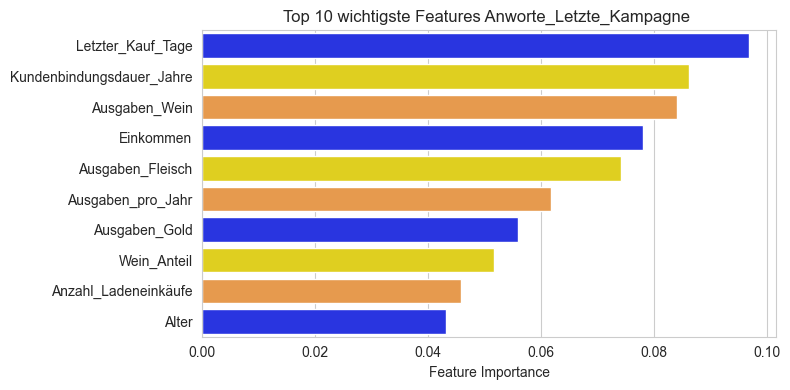

In [44]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=feature_importance_df.head(10),
    x='Importance',
    y='Feature',
    palette=["#0A1AFF", "#FFEA00", "#FF9A35"]
)

plt.title("Top 10 wichtigste Features Anworte_Letzte_Kampagne ")
plt.xlabel("Feature Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()